# Algoritmo genético para N reinas con DEAP

Este notebook desarrolla paso a paso el ejemplo de N reinas presentado en **IPD434 · Seminario de Soft Computing**. Actualiza y amplía el notebook `03_DEAP.ipynb`.

El material está basado en el trabajo desarrollado por el **Prof. Nicolás Gálvez Ramírez** y fue reorganizado para mantener coherencia con la presentación `03_ComputacionEvolutiva.md`.

## DEAP: una biblioteca para algoritmos evolutivos

[DEAP (*Distributed Evolutionary Algorithms in Python*)](https://deap.readthedocs.io/en/master/) es una biblioteca que entrega componentes reutilizables para construir algoritmos evolutivos en Python.

Permite definir individuos, aptitudes, operadores, poblaciones y estadísticas. La biblioteca ejecuta el flujo que programamos, pero la representación, la función objetivo y el protocolo experimental siguen siendo decisiones nuestras.

## Flujo mínimo de DEAP en este ejemplo

1. **Representar:** codificar una solución como un individuo.
2. **Evaluar:** definir una función que mida su calidad.
3. **Crear tipos:** usar `creator.create` para declarar aptitud e individuo.
4. **Registrar:** usar `toolbox.register` para conectar inicialización y operadores.
5. **Inicializar:** crear y evaluar una población con `toolbox.population` y `toolbox.evaluate`.
6. **Evolucionar:** seleccionar, cruzar, mutar, reevaluar y conservar supervivientes.

La secuencia conceptual es: **individuo → aptitud → población → variación → evaluación → supervivencia**.

## Ejemplo conceptual: definir tipos y registrar operadores

El siguiente bloque resume cómo se conectan las piezas de DEAP. 

```python
from deap import base, creator, tools

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individuo", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("individual", crear_individuo)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluar)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", tools.cxOrdered)
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.25)
```

En el ejemplo real, estas funciones se adaptan a la representación por permutación de N reinas.

## Ejemplo conceptual: una generación evolutiva

Una generación combina evaluación, variación y supervivencia. También es **código conceptual**: sus variables se construirán paso a paso en las celdas siguientes.

```python
poblacion = toolbox.population(n=160)

for individuo in poblacion:
    individuo.fitness.values = toolbox.evaluate(individuo)

padres = toolbox.select(poblacion, k=len(poblacion))
hijos = list(map(toolbox.clone, padres))
toolbox.mate(hijos[0], hijos[1])
toolbox.mutate(hijos[0])

for hijo in hijos:
    del hijo.fitness.values
    hijo.fitness.values = toolbox.evaluate(hijo)

poblacion = seleccionar_supervivientes(hijos)
```

El notebook implementará este flujo con validaciones, elitismo y un presupuesto explícito de evaluaciones.

## Objetivos del trabajo práctico

Al completar el notebook se espera poder:

1. formular N reinas como un problema de búsqueda
2. explicar por qué una permutación es una representación conveniente
3. relacionar la representación con la evaluación y los operadores
4. implementar selección, recombinación, mutación y supervivencia con DEAP
5. evaluar el comportamiento estocástico mediante varias semillas y un presupuesto común

## Preparación · Dependencias

Si las dependencias no están instaladas, se pueden incorporar desde una celda con `%pip install deap numpy matplotlib`. Luego conviene reiniciar el kernel.

## Formulación del problema

El objetivo es ubicar $n$ reinas en un tablero de $n \times n$ sin que dos se ataquen. En este notebook se combinan dos ideas de la presentación:

- **CSP**, Problema de Satisfacción de Restricciones: una solución es válida cuando no contiene conflictos
- **FOP**, Problema de Optimización Libre: se minimiza una función que cuenta conflictos
- **CSOP o COP**, Problema de Optimización y Satisfacción de Restricciones o Problema de Optimización Restringido: la representación cumple fila y columna por construcción, mientras la evaluación minimiza conflictos diagonales

La meta computacional será encontrar un individuo con cero conflictos diagonales.

## Representación por permutación

<div style="text-align:center"><img src="../images/nqueens.png" alt="Ejemplo de tablero de N reinas" width="28%"></div>

El individuo es un vector $x=(x_0,\ldots,x_{n-1})$. La posición $i$ representa una columna y el valor $x_i$ indica la fila de su reina. En el código se usan índices entre 0 y $n-1$.

Al exigir que $x$ sea una permutación de `range(n)`, cada columna y cada fila contiene exactamente una reina. Por lo tanto, solo deben evaluarse las diagonales. El espacio disminuye desde $n^n$ vectores posibles a $n!$ permutaciones.

In [43]:
import random

import matplotlib.pyplot as plt
import numpy as np
from deap import base, creator, tools

# creator: permite definir nuevos tipos de individuos y fitness  
# base: contiene el Toolbox, donde se registran funciones personalizadas  
# tools: provee operadores evolutivos listos para usar (selección, mutación, cruzamiento)

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


## Preparación · Configuración y reproducibilidad

Los parámetros se declaran en un solo lugar. La probabilidad de mutación se aplica al individuo completo. `PROB_GEN_SHUFFLE` controla la probabilidad de considerar cada posición dentro del operador de mutación. Son decisiones diferentes.

La semilla permite repetir una ejecución. Para estudiar variabilidad se usarán varias semillas independientes al final.

In [44]:
N = 8
TAM_POBLACION = 160
PROB_CRUCE = 0.80
PROB_MUTACION = 0.25
PROB_GEN_SHUFFLE = 2 / N
TAM_TORNEO = 3
N_ELITE = 1
PRESUPUESTO_EVALUACIONES = 12000
SEMILLA = 0

random.seed(SEMILLA)
np.random.seed(SEMILLA)

# Función auxiliar para visualizar el tablero real
def dibujar_tablero(individuo, titulo="Solución"):
    # índice = columna, valor = fila.
    n = len(individuo)
    colores = np.add.outer(np.arange(n), np.arange(n)) % 2
    _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(colores, cmap="Greys", vmin=0, vmax=1)

    for columna, fila in enumerate(individuo):
        color = "white" if colores[fila, columna] else "black"
        ax.text(columna, fila, "♛", ha="center", va="center", fontsize=24, color=color)

    ax.set(xticks=range(n), yticks=range(n), xlabel="Columna", ylabel="Fila", title=titulo)
    plt.show()

## Etapa 1 · Definir la función de aptitud

Dos reinas ubicadas en las columnas $i$ y $j$ comparten una diagonal cuando

$$|x_i-x_j|=|i-j|$$

La aptitud cuenta todos los pares en conflicto. El problema es de minimización y una solución se reconoce por $C(x)=0$. DEAP espera que la evaluación retorne una tupla, incluso cuando existe un solo objetivo.

In [45]:
def conflictos_diagonales(individuo):
    conflictos = sum(
        abs(individuo[i] - individuo[j]) == abs(i - j)
        for i in range(len(individuo))
        for j in range(i + 1, len(individuo))
    )
    # DEAP espera una tupla de valores, incluso cuando hay un solo objetivo.
    return (conflictos,)


def es_permutacion(individuo):
    return sorted(individuo) == list(range(len(individuo)))


solucion_conocida_8 = [0, 4, 7, 5, 2, 6, 1, 3]
assert es_permutacion(solucion_conocida_8)
assert conflictos_diagonales(solucion_conocida_8) == (0,)
print("Prueba superada. La solución conocida tiene cero conflictos")

Prueba superada. La solución conocida tiene cero conflictos


## Etapa 2 · Crear tipos de aptitud e individuo

`weights=(-1.0,)` indica que el único objetivo debe minimizarse. El individuo hereda de `list` y obtiene un atributo `fitness`. Las comprobaciones con `hasattr` permiten volver a ejecutar la celda sin intentar crear las mismas clases otra vez.

In [ ]:
# creator.create registra clases que DEAP usará como aptitud e individuo.
if not hasattr(creator, "FitnessNReinasMin"):
    # Un peso negativo indica que la aptitud se debe minimizar.
    creator.create("FitnessNReinasMin", base.Fitness, weights=(-1.0,))

if not hasattr(creator, "IndividuoNReinas"):
    # El individuo es una lista con un atributo fitness administrado por DEAP.
    creator.create(
        "IndividuoNReinas",
        list,
        fitness=creator.FitnessNReinasMin,
    )

## Etapa 3 · Registrar el toolbox y los operadores

La inicialización usa `random.sample` para producir permutaciones. El cruzamiento ordenado y la mutación por intercambio conservan esa estructura. Un cruzamiento común para vectores, como el cruzamiento de un punto, podría repetir filas y eliminar otras.

In [ ]:
def crear_toolbox(n, tam_torneo=3, prob_gen=None):
    if prob_gen is None:
        prob_gen = 2 / n

    toolbox = base.Toolbox()
    # register crea nombres de acceso para funciones y sus argumentos fijos.
    toolbox.register("permutacion", random.sample, range(n), n)
    # initIterate construye un individuo aplicando el generador de permutaciones.
    toolbox.register("individual", tools.initIterate, creator.IndividuoNReinas, toolbox.permutacion)
    # initRepeat repite la creación de individuos para formar una población.
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    # Estos alias permiten que el ciclo evolutivo sea independiente del operador concreto.
    toolbox.register("evaluate", conflictos_diagonales)
    toolbox.register("select", tools.selTournament, tournsize=tam_torneo)
    toolbox.register("mate", tools.cxOrdered)
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=prob_gen)
    return toolbox


toolbox = crear_toolbox(N, TAM_TORNEO, PROB_GEN_SHUFFLE)

## Etapa 4 · Crear y evaluar la población

Una población mantiene varias hipótesis de solución al mismo tiempo. Al crearla, cada individuo todavía posee una aptitud inválida porque no ha sido evaluado. La evaluación asigna el valor que utilizarán la selección y la supervivencia.

Individuo: [6, 7, 3, 0, 2, 5, 1, 4]
Es permutación: True
Aptitud válida antes de evaluar: False
Conflictos diagonales: 3.0
Aptitud válida después de evaluar: True


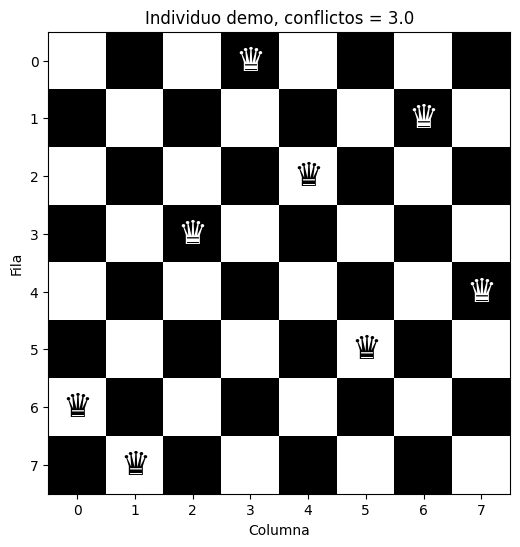

In [46]:
individuo_demo = toolbox.individual()
print("Individuo:", individuo_demo)
print("Es permutación:", es_permutacion(individuo_demo))
print("Aptitud válida antes de evaluar:", individuo_demo.fitness.valid)

# Asignar la tupla a fitness.values calcula y marca la aptitud como válida.
individuo_demo.fitness.values = toolbox.evaluate(individuo_demo)
print("Conflictos diagonales:", individuo_demo.fitness.values[0])
print("Aptitud válida después de evaluar:", individuo_demo.fitness.valid)

dibujar_tablero(
    individuo_demo,
    titulo=f"Individuo demo, conflictos = {individuo_demo.fitness.values[0]}",
)

In [ ]:
poblacion_demo = toolbox.population(n=8)
# DEAP no evalúa automáticamente los individuos al crear la población.
for individuo in poblacion_demo:
    # La aptitud queda disponible para selección y comparación de supervivientes.
    individuo.fitness.values = toolbox.evaluate(individuo)

for numero, individuo in enumerate(poblacion_demo, start=1):
    print(f"{numero:2d}: conflictos={individuo.fitness.values[0]:2.0f}  {individuo}")

# Mostramos solo algunos individuos para no saturar la salida del notebook.
for numero, individuo in enumerate(poblacion_demo[:3], start=1):
    dibujar_tablero(
        individuo,
        titulo=f"Población demo · individuo {numero}, conflictos = {individuo.fitness.values[0]}",
    )

## Etapa 5 · Aplicar selección, recombinación y mutación

La selección por torneo elige padres según su aptitud. DEAP devuelve referencias a los individuos originales, por lo que se deben clonar antes de modificarlos.

La recombinación ordenada combina información de dos padres. La mutación intercambia posiciones y permite explorar alternativas. Ninguna operación garantiza una mejora. La calidad solo se conoce después de evaluar los hijos.

In [ ]:
# selTournament devuelve referencias a individuos existentes, no copias independientes.
padres = toolbox.select(poblacion_demo, k=2)
# Se clonan antes de variar porque mate y mutate modifican los individuos in situ.
hijos = list(map(toolbox.clone, padres))

print("Padres")
print(hijos[0])
print(hijos[1])

toolbox.mate(hijos[0], hijos[1])
toolbox.mutate(hijos[0])

for hijo in hijos:
    # Después de cambiar un individuo, su aptitud anterior ya no es confiable.
    if hijo.fitness.valid:
        del hijo.fitness.values
    assert es_permutacion(hijo)

print("\nHijos después de la variación")
print(hijos[0])
print(hijos[1])
print("Aptitudes válidas:", [hijo.fitness.valid for hijo in hijos])

for numero, hijo in enumerate(hijos, start=1):
    dibujar_tablero(hijo, titulo=f"Hijo {numero} después de la variación")

## Etapa 6 · Definir el ciclo evolutivo

```text
P ← inicializar población
evaluar P
mientras quede presupuesto y no exista una solución:
    padres ← seleccionar(P)
    hijos ← recombinar y mutar copias de los padres
    evaluar hijos
    P ← seleccionar supervivientes entre hijos y élite
retornar la mejor solución observada
```

El algoritmo evaluará toda la población inicial y toda la descendencia de cada generación. De este modo, el presupuesto máximo se expresa directamente como una cantidad de evaluaciones de aptitud.

In [ ]:
def evaluar_poblacion(poblacion, toolbox):
    for individuo in poblacion:
        # fitness.values recibe la tupla retornada por la función registrada como evaluate.
        individuo.fitness.values = toolbox.evaluate(individuo)
    return len(poblacion)


def resumir_generacion(poblacion, generacion, evaluaciones):
    valores = np.asarray([ind.fitness.values[0] for ind in poblacion])
    unicos = len({tuple(ind) for ind in poblacion})
    return {
        "generacion": generacion,
        "evaluaciones": evaluaciones,
        "mejor": int(valores.min()),
        "promedio": float(valores.mean()),
        "desviacion": float(valores.std()),
        "diversidad": unicos / len(poblacion),
    }

In [ ]:
def ejecutar_ga(
    semilla,
    n=N,
    tam_poblacion=TAM_POBLACION,
    prob_cruce=PROB_CRUCE,
    prob_mutacion=PROB_MUTACION,
    prob_gen=None,
    tam_torneo=TAM_TORNEO,
    n_elite=N_ELITE,
    presupuesto=PRESUPUESTO_EVALUACIONES,
):
    random.seed(semilla)
    np.random.seed(semilla)
    toolbox_local = crear_toolbox(n, tam_torneo, prob_gen)
    poblacion = toolbox_local.population(n=tam_poblacion)
    # La población inicial también consume evaluaciones del presupuesto.
    evaluaciones = evaluar_poblacion(poblacion, toolbox_local)

    # clone conserva una mejor solución independiente de la población que seguirá cambiando.
    mejor = toolbox_local.clone(tools.selBest(poblacion, 1)[0])
    historial = [resumir_generacion(poblacion, 0, evaluaciones)]
    generaciones_maximas = (presupuesto - tam_poblacion) // tam_poblacion

    for generacion in range(1, generaciones_maximas + 1):
        if mejor.fitness.values[0] == 0:
            break

        # La élite se clona para preservarla mientras se generan y modifican los hijos.
        elite = list(map(toolbox_local.clone, tools.selBest(poblacion, n_elite)))
        # La selección entrega referencias; por eso se vuelven a clonar antes de variar.
        padres = toolbox_local.select(poblacion, k=tam_poblacion)
        hijos = list(map(toolbox_local.clone, padres))

        for hijo_1, hijo_2 in zip(hijos[::2], hijos[1::2]):
            if random.random() < prob_cruce:
                toolbox_local.mate(hijo_1, hijo_2)

        for hijo in hijos:
            if random.random() < prob_mutacion:
                toolbox_local.mutate(hijo)
            # Invalidar la aptitud obliga a reevaluar el hijo en la siguiente línea.
            if hijo.fitness.valid:
                del hijo.fitness.values
            assert es_permutacion(hijo)

        evaluaciones += evaluar_poblacion(hijos, toolbox_local)
        # selBest usa fitness.values para conservar los mejores entre hijos y élite.
        poblacion = tools.selBest(hijos + elite, k=tam_poblacion)
        mejor_generacion = tools.selBest(poblacion, 1)[0]

        if mejor_generacion.fitness.values[0] < mejor.fitness.values[0]:
            # Se clona para que 'mejor' no sea una referencia a un individuo mutable.
            mejor = toolbox_local.clone(mejor_generacion)

        historial.append(resumir_generacion(poblacion, generacion, evaluaciones))

    return {
        "mejor_individuo": mejor,
        "mejor_conflictos": int(mejor.fitness.values[0]),
        "exito": mejor.fitness.values[0] == 0,
        "evaluaciones": evaluaciones,
        "historial": historial,
        "poblacion_final": poblacion,
        "semilla": semilla,
    }

## Etapa 7 · Ejecutar el algoritmo completo

Esta ejecución sirve para observar el ciclo, no para concluir que la configuración es superior. El algoritmo es estocástico y otra semilla puede producir una trayectoria diferente.

In [ ]:
resultado = ejecutar_ga(SEMILLA)

print("Semilla:", resultado["semilla"])
print("Mejor individuo:", resultado["mejor_individuo"])
print("Conflictos diagonales:", resultado["mejor_conflictos"])
print("Éxito:", resultado["exito"])
print("Evaluaciones utilizadas:", resultado["evaluaciones"])

In [ ]:
historial = resultado["historial"]
evaluaciones = [fila["evaluaciones"] for fila in historial]

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].plot(evaluaciones, [fila["promedio"] for fila in historial], label="promedio")
ejes[0].plot(evaluaciones, [fila["mejor"] for fila in historial], label="mejor")
ejes[0].set_xlabel("Evaluaciones de aptitud")
ejes[0].set_ylabel("Conflictos diagonales")
ejes[0].legend()
ejes[0].grid(alpha=0.3)

ejes[1].plot(evaluaciones, [fila["diversidad"] for fila in historial], color="tab:green")
ejes[1].set_xlabel("Evaluaciones de aptitud")
ejes[1].set_ylabel("Proporción de individuos únicos")
ejes[1].set_ylim(0, 1.05)
ejes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [ ]:
dibujar_tablero(
    resultado["mejor_individuo"],
    titulo=f"Mejor solución, conflictos = {conflictos_diagonales(resultado['mejor_individuo'])[0]}",
)

## Referencias

- Material basado en el notebook `03_DEAP.ipynb` desarrollado por el Prof. Nicolás Gálvez Ramírez
- Presentación de la unidad `03_ComputacionEvolutiva.md`
- Documentación de DEAP: <https://deap.readthedocs.io/>
- Eiben, A. E. y Smith, J. E. *Introduction to Evolutionary Computing*. Springer, 2015
- Goldberg, D. E. *Genetic Algorithms in Search, Optimization, and Machine Learning*. Addison Wesley, 1989